In [ ]:
pwd

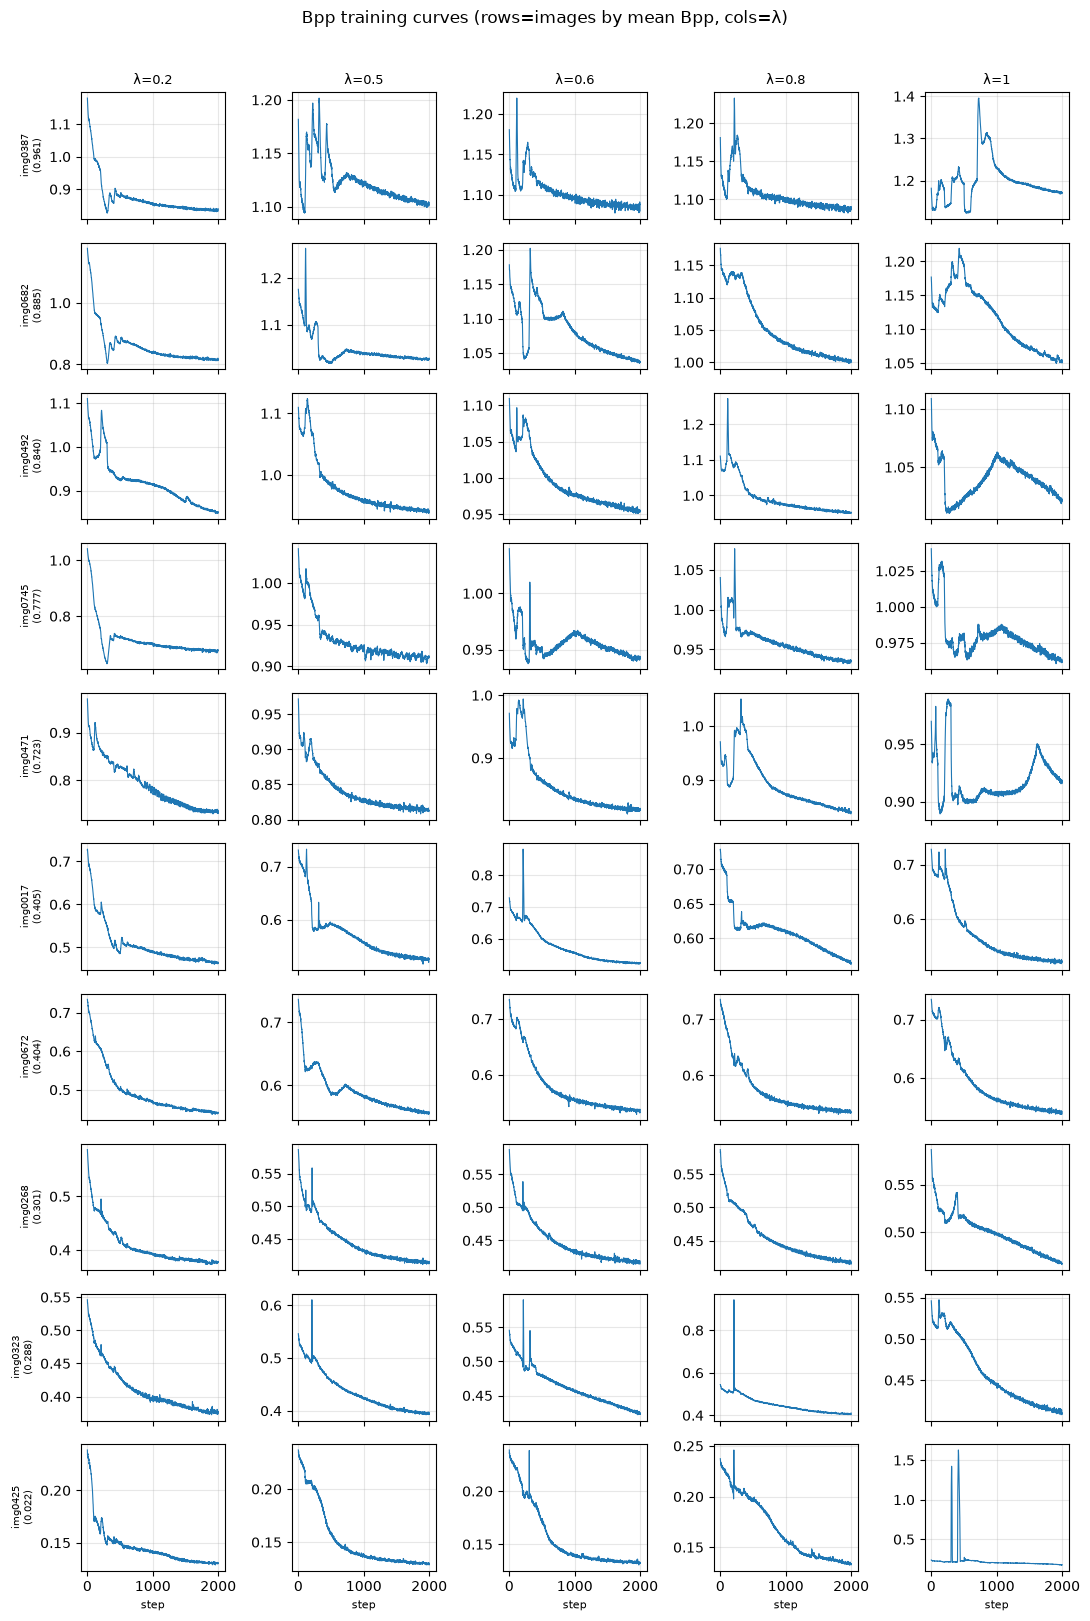

In [9]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/gpfs/data/gpfs0/timofey.glukhikh/Science_Phan/runs/bitrate_sr")
LAMS = ["0.2", "0.5", "0.6", "0.8", "1"]

imgs = list({
    p.name.split("_nina_")[0]
    for p in ROOT.glob("img*_nina_psnr35_lam*_r4")
})

def mean_bpp(img: str) -> float:
    vals = []
    for lam in LAMS:
        mf = ROOT / f"{img}_nina_psnr35_lam{lam}_r4" / "metrics.json"
        if mf.exists():
            vals.append(json.loads(mf.read_text())["Bpp"])
    return float(np.mean(vals)) if vals else float("inf")

# низкий bpp сверху; для наоборот добавь reverse=True
imgs = sorted(imgs, key=mean_bpp, reverse=True)

n_r, n_c = len(imgs), len(LAMS)
fig, axes = plt.subplots(n_r, n_c, figsize=(2.2 * n_c, 1.6 * n_r), sharex=True, sharey=False)

if n_r == 1:
    axes = np.array([axes])

for i, img in enumerate(imgs):
    for j, lam in enumerate(LAMS):
        ax = axes[i, j]
        d = ROOT / f"{img}_nina_psnr35_lam{lam}_r4"
        cpath = d / "curves.npz"
        if not cpath.exists():
            ax.set_axis_off()
            continue
        b = np.load(cpath)["bpp_values"]
        ax.plot(b, lw=0.8)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_title(f"λ={lam}", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{img}\n({mean_bpp(img):.3f})", fontsize=7)
        if i == n_r - 1:
            ax.set_xlabel("step", fontsize=8)

fig.suptitle("Bpp training curves (rows=images by mean Bpp, cols=λ)", y=1.01)
fig.tight_layout()
plt.show()

In [10]:
for lam in ["1", "0.8", "0.6", "0.5", "0.2"]:
    d = ROOT / f"img0268_nina_psnr35_lam{lam}_r4"
    m = json.loads((d / "metrics.json").read_text())
    b = np.load(d / "curves.npz")["bpp_values"]
    print(f"λ={lam}: metric_Bpp={m['Bpp']:.4f}  curve {b[0]:.4f}->{b[-1]:.4f}  min={b.min():.4f}")

λ=1: metric_Bpp=0.3489  curve 0.5871->0.4667  min=0.4657
λ=0.8: metric_Bpp=0.2987  curve 0.5869->0.4181  min=0.4144
λ=0.6: metric_Bpp=0.3003  curve 0.5876->0.4146  min=0.4136
λ=0.5: metric_Bpp=0.2962  curve 0.5867->0.4128  min=0.4110
λ=0.2: metric_Bpp=0.2606  curve 0.5874->0.3783  min=0.3729
